# PHYS 332 - Numerical Techniques for the Sciences II
## Homework 02: Ordinary Differential Equations
### Problem 2 -  Sturm-Liouville Solver
---
Name: *Ethan Duarte*

Cells for *Problem 2* are below.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

### Solver for a Sturm-Liouville Problem (Finite String Eigenmodes)

Note that everything you build here generalizes to any BVP that can be solved by a shooting method.

## Part A: The ODEs

First, input the three differential equations that will be the RHS of your equation here. 

In [2]:
def dydx_string(x,y,**kwargs):

    """
    RHS function (dydx) for the (non-)uniform string.

    PARAMETERS:
    input:
        x -- position along the string
        y -- state vector with three elements

    RETURNS:
        dydx : array containing the three derivatives y'(x), y''(x),
               and lambda'(x)
    """

    dydx = np.zeros(3)

    ## Your code goes here
    dydx[0] = y[1]
    dydx[1] = -(y[2] * np.pi)**2 * rho(x, **kwargs) * y[0]
    dydx[2] = 0
    

    return dydx

## Part B: The Density Function

Here we make use of Python's optional keyword arguments: `rho(x,imode=0)` should return the flat density, and `rho(x,imode=1)` the exponential one.  

In [3]:
def rho(x,**kwargs):

    """
    Returns the mass density of the string at position x.

    PARAMETERS:
    input:
        x     -- position along the string
        imode -- (keyword argument) density profile:
                 0 for flat, 1 for exponential

    RETURNS:
        r : the density rho(x)
    """

    imode = kwargs.get('imode',0)

    if (imode == 0):   # flat
        ## Your code goes here
        r = 1
    elif (imode == 1): # exponential
        ## Your code goes here
        r = 1 + np.exp(10 * x)

    return r

## Part C: The Integrator

Implement the RK4 integrator from HW01 (or just copy your old solution, or the one from my solution sets).  **NOTE** you will have to add the additional kwargs to change between a flat or exponential density profile (the imode keyword) inside your `rk4step`, but otherwise your old function should work just fine.

Note that we're using RK4, as opposed to the (objectively better) RK45, because we need an IVP solver that ends *exactly* at the right-most part of our boundary.  Because our RK45 takes whatever step it deems most suitable based on the error tolerance, it will frequently *overshoot* the boundary.  

You can fix this in practice (e.g. by forcing the RK45 to take a step exactly equal to the remaining part of the interval when it gets close enough), but for our purposes here RK4 will be just fine.  Just make sure your implementation goes exactly to the end of the interval you've asked it to!

In [4]:
def rk4step(y, f, x, h, **kwargs):
    """
    Advances solution by a single RK4 step
    
    PARAMETERS:
    input:
        y -- initial value, scalar;
        f -- function (RHS of ODE);
        x -- starting x.
        h -- stepsize

    RETURNS:
        updated result

        See the assignment sheet for additional details about these
        function parameters.
    """

    ## Your code goes here
    k1 = h * f(x, y, **kwargs)
    k2 = h * f(x + h/2, y + k1/2, **kwargs)
    k3 = h * f(x + h/2, y + k2/2, **kwargs)
    k4 = h * f(x + h, y + k3, **kwargs)

    ynew = y + (k1 + 2*k2 + 2*k3 + k4)/6

    return ynew

def ode_fixedstep(nstep,f,x0,y0,x1,iinteg,**kwargs):

    """
    Solves an ordinary differential equation
    using fixed step size.

    PARAMETERS:
    input:
        nstep -- number of steps
        f     -- inline function (RHS of ODE)
        x0    -- starting x.
        y0    -- starting y (scalar).
        x1    -- end x.
        imode -- (keyword argument) density profile:
                 0 for flat, 1 for exponential

    output:
        x      : positions of n+1 steps
        y      : (nstep+1,1) vector of resulting y's
    
     comment  : Determine dx from the given stepsize and the integration
                boundaries. You will have to provide the integrators
                through functions eulerstep, rk2step, rk4step.
                Each of them does just one single step.

    """
    h = (x1-x0)/nstep
    x = np.linspace(x0,x1,nstep+1)
    
    y = np.zeros((nstep+1, len(y0)))
    y[0] = y0

    for i in range(nstep):
        y[i+1] = iinteg(y[i], f, x[i], h, **kwargs)
        
    return x,y

## Part D: The "Trial Shot" Function

In [5]:
def load_string(v):

    """
    Boundary "loading" function for the string problem.

    PARAMETERS:
    input:
        v -- the eigenvalue guess, i.e. lambda (array with one element)

    RETURNS:
        x0,x1 : the integration boundaries
        y     : array with three elements, containing the initial
                values at x=0

        Note that some of the initial values in y can (and should!)
        depend on lambda.
    """

    ## Your code goes here
    x0 = 0
    x1 = 1

    y = np.array([0, v[0] * np.pi, v[0]])

    return x0,x1,y

In [6]:
def score_string(x,y):

    """
    Scoring function for the string problem.

    PARAMETERS:
    input:
        x -- positions returned by the integrator
        y -- solution array returned by the integrator

    RETURNS:
        score : the function that needs to be zeroed by the root
                finder.  In our case, that's just y(1) -- the
                displacement at the far boundary should be zero.
    """

    ## Your code goes here
    score = y[-1,0]

    return score

In [7]:
def bvp_shoot(dydx_string,
              ode_fixedstep,
              load_string,
              score_string,
              v,
              nstep,
              **kwargs):

    """
    A single trial shot.  Sets the initial values (guesses) via load_string,
    calculates the corresponding solution via ode_fixedstep, and returns a
    "score" via score_string, i.e. a value for the root finder to zero out.

    PARAMETERS:
    input:
        dydx_string    -- function (RHS of ODE, here dydx_string)
        ode_fixedstep  -- stepper (here rk4)
        load_string    -- loading function (here load_string)
        score_string   -- scoring function (here score_string)
        v              -- guess for the eigenvalue lambda
        nstep          -- number of integration steps

    RETURNS:
        score : this should be zero when v is an eigenvalue, and thus
                can be directly used by the root finder.
    """

    ## Your code goes here

    x0, x1, y0 = load_string(v)

    x, y = ode_fixedstep(
        nstep,
        dydx_string,
        x0,
        y0,
        x1,
        rk4step,
        **kwargs
    )

    score = score_string(x, y)

    return score

## Part E: The Root Finder

In [8]:
def bvp_root(dydx_string,
             ode_fixedstep,
             load_string,
             score_string,
             v0,
             nstep,
             **kwargs):

    """
    The root finder.  Brackets the root starting from the initial
    guess v0, then finds it via bisection.  Each "function evaluation"
    is a call to bvp_shoot.

    PARAMETERS:
    input:
        dydx_string    -- function (RHS of ODE, here dydx_string)
        ode_fixedstep  -- stepper (here rk4)
        load_string    -- loading function (here load_string)
        score_string   -- scoring function (here score_string)
        v0              -- guess for the eigenvalue lambda
        nstep          -- number of integration steps


    RETURNS:
        x : positions of the nstep+1 support points
        y : (3,nstep+1) solution array, so that the solution can
            be plotted
    """

    ## Your code goes here
    ## hint: once your bisection has converged on the eigenvalue,
    ## you'll want to do one last integration to get the full
    ## solution x,y to return

    va = v0
    fa = bvp_shoot(
        dydx_string,
        ode_fixedstep,
        load_string,
        score_string,
        va,
        nstep,
        **kwargs
    )
    
    i = 1
    vb = v0 * 1.1**i
    
    fb = bvp_shoot(
        dydx_string,
        ode_fixedstep,
        load_string,
        score_string,
        vb,
        nstep,
        **kwargs
    )
    
    while fa * fb > 0:
    
        i += 1
        vb = v0 * 1.1**i
    
        fb = bvp_shoot(
            dydx_string,
            ode_fixedstep,
            load_string,
            score_string,
            vb,
            nstep,
            **kwargs
        )
    
    while np.abs(vb[0] - va[0]) > 1e-10:
    
        vmid = (va + vb) / 2
    
        fmid = bvp_shoot(
            dydx_string,
            ode_fixedstep,
            load_string,
            score_string,
            vmid,
            nstep,
            **kwargs
        )
    
        if fa * fmid < 0:
            vb = vmid
            fb = fmid
        else:
            va = vmid
            fa = fmid
    
    v = (va + vb) / 2
    
    x0,x1,y0 = load_string(v)
    
    x,y = ode_fixedstep(
        nstep,
        dydx_string,
        x0,
        y0,
        x1,
        rk4step,
        **kwargs
    )

    return x,y

## Part F: The Main Program

In [9]:
nstep = 500                # number of integration steps
imode = 0                  # density profile: 0 for flat, 1 for exponential
v0    = np.array([0.5])    # initial guess for the eigenvalue

x,y   = bvp_root(dydx_string,ode_fixedstep,load_string,score_string,v0,nstep,imode = imode)


Eigenvalue: 1.000000000013749


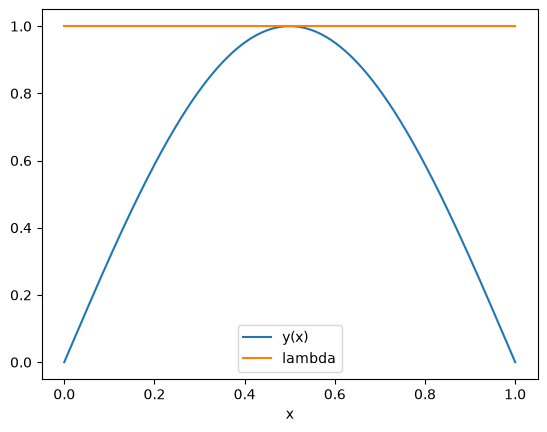

In [10]:
## Plot your answer here, pulling out the appropriate part of the y vector
print("Eigenvalue:", y[0,2])

plt.plot(x, y[:,0], label="y(x)")
plt.plot(x, y[:,2], label="lambda")

plt.xlabel("x")
plt.legend()
plt.show()

## Part G: Tests (1)

Initial guess: 0.5
Eigenvalue: 1.000000000013749
Initial guess: 1.5
Eigenvalue: 2.000000000386019


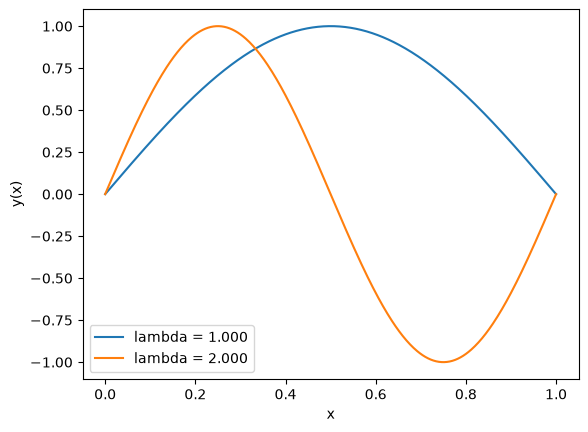

In [11]:
## Your code goes here
for guess in [0.5, 1.5]:

    v0 = np.array([guess])

    x,y = bvp_root(
        dydx_string,
        ode_fixedstep,
        load_string,
        score_string,
        v0,
        nstep,
        imode=0
    )

    print("Initial guess:", guess)
    print("Eigenvalue:", y[0,2])

    plt.plot(x, y[:,0], label=f"lambda = {y[0,2]:.3f}")

plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.show()

## Part H: Tests (2)


Guess 0.5 gives lambda = 0.5736201575561428
This is eigenvalue number 17


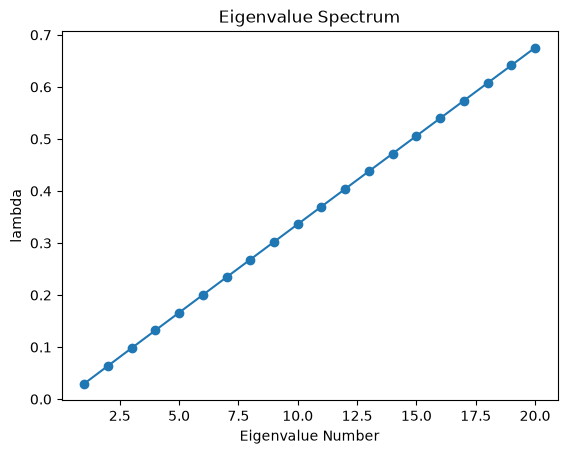

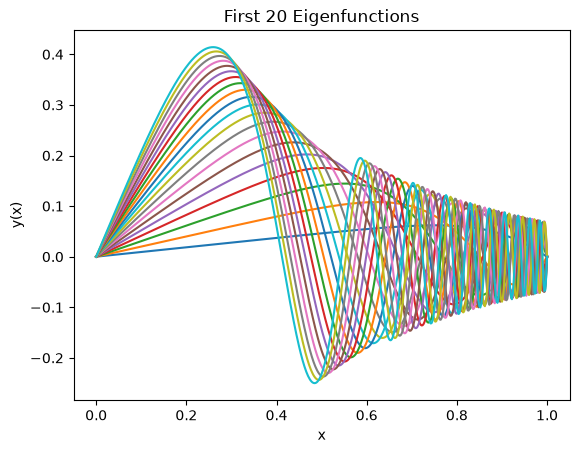

In [12]:
## Your code goes here
eigenvalues = []
eigenfunctions = []

v0 = np.array([0.01])

for i in range(20):

    x,y = bvp_root(
        dydx_string,
        ode_fixedstep,
        load_string,
        score_string,
        v0,
        nstep,
        imode=1
    )

    eigenvalue = y[0,2]

    eigenvalues.append(eigenvalue)
    eigenfunctions.append(y[:,0])

    v0 = np.array([eigenvalue * 1.001])

x_half,y_half = bvp_root(
    dydx_string,
    ode_fixedstep,
    load_string,
    score_string,
    np.array([0.5]),
    nstep,
    imode=1
)

lambda_half = y_half[0,2]

mode = np.argmin(
    np.abs(np.array(eigenvalues) - lambda_half)
) + 1

print("Guess 0.5 gives lambda =", lambda_half)
print("This is eigenvalue number", mode)

plt.plot(
    np.arange(1,21),
    eigenvalues,
    marker="o"
)

plt.xlabel("Eigenvalue Number")
plt.ylabel("lambda")
plt.title("Eigenvalue Spectrum")
plt.show()

for i in range(20):
    plt.plot(x, eigenfunctions[i])

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("First 20 Eigenfunctions")
plt.show()